# Building Stock Analysis

This notebook describes the filtered Hamburg residential building stock before typology matching or material-intensity application.

Residential buildings are selected in `03_residential_building_filter.ipynb` using explicit `gebaeudefunktion` codes. This notebook keeps all selected residential buildings in the building-stock analysis, even when construction year or storey information is missing. Missing attributes are reported as coverage/quality information rather than used as exclusion criteria.


In [1]:
from pathlib import Path
import re

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

DATA_PATH = Path("../data/raw/hamburg_buildings_clean.gpkg")
PROCESSED_DIR = Path("../data/processed")
MAP_DIR = Path("../results/maps")
RESIDENTIAL_FUNCTION_FILTER_PATH = PROCESSED_DIR / "hamburg_main_residential_buildings_by_function.gpkg"
RESIDENTIAL_ANALYSIS_PATH = PROCESSED_DIR / "residential_buildings_for_analysis.gpkg"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 120)


MAIN_RESIDENTIAL_FUNCTION_CODES = {
    1010: "Wohnhaus",
    1020: "Wohnheim",
    1100: "Gemischt genutztes Gebaeude mit Wohnen",
    1110: "Wohngebaeude mit Gemeinbedarf",
    1120: "Wohngebaeude mit Handel und Dienstleistungen",
    1130: "Wohngebaeude mit Gewerbe und Industrie",
    1210: "Land- und forstwirtschaftliches Wohngebaeude",
    1220: "Land- und forstwirtschaftliches Wohn- und Betriebsgebaeude",
}

EXCLUDED_RESIDENTIAL_RELATED_CODES = {
    1311: "Ferienhaus",
    1312: "Wochenendhaus",
    1313: "Gartenhaus",
}

MAIN_RESIDENTIAL_CODE_SET = set(MAIN_RESIDENTIAL_FUNCTION_CODES)
EXCLUDED_RESIDENTIAL_RELATED_CODE_SET = set(EXCLUDED_RESIDENTIAL_RELATED_CODES)

BAUWEISE_CODE_LABELS = {
    "1100": "Freistehendes Einzelgebaeude",
    "2100": "Doppelhaushaelfte",
    "2200": "Reihenhaus",
    "2300": "Haus in Reihe",
    "2400": "Gruppenhaus",
    "1200": "Freistehender Gebaeudeblock",
    "2500": "Gebaeudeblock in geschlossener Bauweise",
    "1300": "Einzelgarage",
    "1400": "Doppelgarage",
    "1500": "Sammelgarage",
    "4000": "Offene Halle",
    "9999": "Unbekannt",
}

BAUWEISE_FORM_MAP = {
    "1100": "SFH",
    "2100": "SFH",
    "2200": "SFH",
    "2300": "SFH",
    "2400": "SFH",
    "1200": "MFH",
    "2500": "MFH",
    "1300": "auxiliary_non_residential",
    "1400": "auxiliary_non_residential",
    "1500": "auxiliary_non_residential",
    "4000": "non_residential",
    "9999": "unresolved",
}


In [2]:
CURRENT_YEAR_MAX = 2026


def clean_baujahr(value):
    if pd.isna(value):
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "missing"})

    text = str(value).strip()
    if text == "" or text.upper() == "NULL":
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "missing"})

    years = [int(year) for year in re.findall(r"\d{4}", text)]
    if not years:
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "missing"})

    plausible_years = [year for year in years if 1500 < year <= CURRENT_YEAR_MAX]

    if years == [1500] or (not plausible_years and 1500 in years):
        return pd.Series({"construction_year": pd.NA, "construction_year_status": "invalid_placeholder_1500"})

    if len(plausible_years) == 1 and len(years) == 1:
        return pd.Series({"construction_year": plausible_years[0], "construction_year_status": "single_year"})

    if plausible_years:
        return pd.Series({
            "construction_year": min(plausible_years),
            "construction_year_status": "multiple_years_earliest_used" if len(years) > 1 else "single_year",
        })

    return pd.Series({"construction_year": pd.NA, "construction_year_status": "invalid_or_unusable"})


def non_missing_attribute(series):
    values = series.astype("string").str.strip()
    return values.notna() & values.ne("") & values.str.upper().ne("NULL")


def normalize_bauweise_code(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text == "" or text.upper() == "NULL":
        return ""
    numeric = pd.to_numeric(text, errors="coerce")
    if pd.notna(numeric) and float(numeric).is_integer():
        return str(int(numeric))
    return text


def classify_bauweise_form(value):
    code = normalize_bauweise_code(value)
    if code == "":
        return "unresolved"
    return BAUWEISE_FORM_MAP.get(code, "unresolved")


def add_base_columns(gdf):
    result = gdf.copy()
    baujahr_cleaned = result["baujahr"].apply(clean_baujahr)
    result = result.join(baujahr_cleaned)
    result["construction_year"] = pd.to_numeric(result["construction_year"], errors="coerce")
    result["storeys"] = pd.to_numeric(
        result["anzahlDerOberirdischenGeschosse"],
        errors="coerce",
    )
    result["building_function"] = pd.to_numeric(result["gebaeudefunktion"], errors="coerce")
    return result


def residential_function_mask(gdf):
    if "is_main_residential_stock" in gdf.columns:
        return gdf["is_main_residential_stock"].fillna(False).astype(bool)
    return gdf["building_function"].isin(MAIN_RESIDENTIAL_CODE_SET)


def make_scope_masks(gdf):
    has_construction_year = gdf["construction_year"].notna()
    has_valid_storeys = (
        gdf["storeys"].notna()
        & (gdf["storeys"] > 0)
        & gdf["storeys"].mod(1).eq(0)
    )
    is_residential = residential_function_mask(gdf)
    return {
        "has_construction_year": has_construction_year,
        "has_valid_storeys": has_valid_storeys,
        "is_residential": is_residential,
        "analysis_scope": is_residential,
    }


def validate_bauweise_storeys(form, storeys):
    if form not in {"SFH", "MFH"}:
        return "not_applicable"
    if pd.isna(storeys) or not float(storeys).is_integer():
        return "storeys_missing_or_non_integer"
    if form == "SFH" and 1 <= storeys <= 3:
        return "ok"
    if form == "MFH" and 3 <= storeys <= 8:
        return "ok"
    return "outside_expected_range"


def validate_bauweise_footprint(form, footprint_area):
    if form not in {"SFH", "MFH"}:
        return "not_applicable"
    if pd.isna(footprint_area) or footprint_area <= 0:
        return "footprint_missing_or_invalid"
    if form == "SFH" and footprint_area <= 500:
        return "ok"
    if form == "MFH" and footprint_area >= 100:
        return "ok"
    return "outside_expected_range"


def combine_bauweise_quality_flags(row):
    if row["bauweise_direct_form"] not in {"SFH", "MFH"}:
        return "not_applicable"
    flags = []
    if row["bauweise_storey_validation"] != "ok":
        flags.append(f"storeys:{row['bauweise_storey_validation']}")
    if row["bauweise_footprint_validation"] != "ok":
        flags.append(f"footprint:{row['bauweise_footprint_validation']}")
    return "ok" if not flags else ";".join(flags)


def add_stock_columns(gdf):
    result = add_base_columns(gdf)
    result["footprint_area"] = result.geometry.area
    result["bauweise_code"] = result["bauweise"].apply(normalize_bauweise_code)
    result["bauweise_label"] = result["bauweise_code"].map(BAUWEISE_CODE_LABELS).fillna("Unmapped or missing")
    result["bauweise_direct_form"] = result["bauweise_code"].apply(classify_bauweise_form)
    result["bauweise_storey_validation"] = result.apply(
        lambda row: validate_bauweise_storeys(row["bauweise_direct_form"], row["storeys"]),
        axis=1,
    )
    result["bauweise_footprint_validation"] = result.apply(
        lambda row: validate_bauweise_footprint(row["bauweise_direct_form"], row["footprint_area"]),
        axis=1,
    )
    result["bauweise_quality_flags"] = result.apply(combine_bauweise_quality_flags, axis=1)
    return result


def dataset_summary(gdf, masks, original_building_count=None):
    denominator = original_building_count if original_building_count is not None else len(gdf)
    rows = [
        ("Original Hamburg buildings", denominator),
        ("Buildings selected by residential function filter", len(gdf)),
        ("Residential buildings retained for stock analysis", int(masks["analysis_scope"].sum())),
        ("Residential buildings with valid construction year", int((masks["analysis_scope"] & masks["has_construction_year"]).sum())),
        ("Residential buildings with missing/invalid construction year", int((masks["analysis_scope"] & ~masks["has_construction_year"]).sum())),
        ("Residential buildings with invalid placeholder year 1500", int((masks["analysis_scope"] & gdf["construction_year_status"].eq("invalid_placeholder_1500")).sum())),
        ("Residential buildings with valid storeys", int((masks["analysis_scope"] & masks["has_valid_storeys"]).sum())),
        ("Residential buildings with missing/invalid storeys", int((masks["analysis_scope"] & ~masks["has_valid_storeys"]).sum())),
    ]
    summary = pd.DataFrame(rows, columns=["metric", "building_count"])
    summary["share_of_original_pct"] = (summary["building_count"] / denominator * 100).round(2)
    return summary


def building_function_summary(gdf):
    summary = (
        gdf.groupby(["gebaeudefunktion", "building_function"], dropna=False)
        .size()
        .reset_index(name="building_count")
        .sort_values("building_count", ascending=False)
    )
    summary["share_pct"] = (summary["building_count"] / len(gdf) * 100).round(2)
    summary["residential_function_scope"] = (
        summary["building_function"].isin(MAIN_RESIDENTIAL_CODE_SET)
    )
    return summary


def construction_year_coverage_by_group(masks):
    is_residential = masks["is_residential"]
    has_construction_year = masks["has_construction_year"]
    coverage = pd.DataFrame({
        "building_group": ["Residential buildings", "Other buildings"],
        "total_buildings": [int(is_residential.sum()), int((~is_residential).sum())],
        "buildings_with_valid_construction_year": [
            int((is_residential & has_construction_year).sum()),
            int(((~is_residential) & has_construction_year).sum()),
        ],
    })
    coverage["valid_construction_year_coverage_percent"] = (
        coverage["buildings_with_valid_construction_year"] / coverage["total_buildings"] * 100
    ).round(2)
    return coverage


def attribute_coverage(gdf):
    dachform_info = non_missing_attribute(gdf["dachform"])
    dachart_info = non_missing_attribute(gdf["dachart"])
    roof_info = dachform_info | dachart_info
    bauweise_info = non_missing_attribute(gdf["bauweise"])
    coverage = pd.DataFrame([
        {"attribute": "dachform", "buildings_with_info": int(dachform_info.sum())},
        {"attribute": "dachart", "buildings_with_info": int(dachart_info.sum())},
        {"attribute": "dachform_or_dachart", "buildings_with_info": int(roof_info.sum())},
        {"attribute": "bauweise", "buildings_with_info": int(bauweise_info.sum())},
        {"attribute": "dachform_and_bauweise", "buildings_with_info": int((dachform_info & bauweise_info).sum())},
        {"attribute": "dachart_and_bauweise", "buildings_with_info": int((dachart_info & bauweise_info).sum())},
        {"attribute": "dachform_or_dachart_and_bauweise", "buildings_with_info": int((roof_info & bauweise_info).sum())},
    ])
    coverage["share_of_all_buildings_pct"] = (coverage["buildings_with_info"] / len(gdf) * 100).round(2)
    return coverage


def bauweise_coverage(gdf):
    coverage = (
        gdf.groupby(["bauweise_code", "bauweise_label", "bauweise_direct_form"], dropna=False)
        .size()
        .reset_index(name="building_count")
        .sort_values("building_count", ascending=False)
    )
    coverage["share_pct"] = (coverage["building_count"] / len(gdf) * 100).round(2)
    return coverage


## Load Residential Building Stock and Define Analysis Scope


In [3]:
gdf_all = gpd.read_file(DATA_PATH)

if RESIDENTIAL_FUNCTION_FILTER_PATH.exists():
    gdf_residential_input = gpd.read_file(RESIDENTIAL_FUNCTION_FILTER_PATH)
    print("Residential function-filtered input:", RESIDENTIAL_FUNCTION_FILTER_PATH)
else:
    print("Residential function-filtered file not found. Applying the explicit code filter inside this notebook.")
    gdf_all["building_function"] = pd.to_numeric(gdf_all["gebaeudefunktion"], errors="coerce").astype("Int64")
    gdf_all["is_main_residential_stock"] = gdf_all["building_function"].isin(MAIN_RESIDENTIAL_CODE_SET)
    gdf_residential_input = gdf_all[gdf_all["is_main_residential_stock"]].copy()

gdf_stock = add_stock_columns(gdf_residential_input)
masks = make_scope_masks(gdf_stock)
gdf_residential_stock = gdf_stock.loc[masks["analysis_scope"]].copy()
gdf_residential_stock["construction_year"] = pd.to_numeric(gdf_residential_stock["construction_year"], errors="coerce").astype("Int64")
gdf_residential_stock["storeys"] = pd.to_numeric(gdf_residential_stock["storeys"], errors="coerce")
gdf_residential_stock["building_function"] = pd.to_numeric(gdf_residential_stock["building_function"], errors="coerce").astype("Int64")
gdf_residential_stock["stock_scope"] = "residential_analysis"

print("Original Hamburg buildings:", len(gdf_all))
print("Buildings selected by residential function filter:", len(gdf_stock))
print("Residential buildings retained for stock analysis:", len(gdf_residential_stock))
print("Residential buildings with valid construction year:", int((masks["analysis_scope"] & masks["has_construction_year"]).sum()))
print("Residential buildings with valid storeys:", int((masks["analysis_scope"] & masks["has_valid_storeys"]).sum()))
print("CRS:", gdf_stock.crs)

dataset_summary(gdf_stock, masks, original_building_count=len(gdf_all))


Residential function-filtered input: ../data/processed/hamburg_main_residential_buildings_by_function.gpkg
Original Hamburg buildings: 379320
Buildings selected by residential function filter: 227334
Residential buildings retained for stock analysis: 227334
Residential buildings with valid construction year: 129167
Residential buildings with valid storeys: 227110
CRS: EPSG:25832


,metric,building_count,share_of_original_pct
0,Original Hamburg buildings,379320,100.00
1,Buildings selected by residential function filter,227334,59.93
2,Residential buildings retained for stock analysis,227334,59.93
3,Residential buildings with valid construction ...,129167,34.05
4,Residential buildings with missing/invalid con...,98167,25.88
5,Residential buildings with invalid placeholder...,1763,0.46
6,Residential buildings with valid storeys,227110,59.87
7,Residential buildings with missing/invalid sto...,224,0.06


## Building Function Mix in Selected Residential Stock


In [4]:
building_function_summary(gdf_stock).head(30)


,gebaeudefunktion,building_function,building_count,share_pct,residential_function_scope
0,1010,1010,205239,90.28,True
4,1120,1120,9852,4.33,True
2,1100,1100,8646,3.80,True
1,1020,1020,1403,0.62,True
5,1130,1130,889,0.39,True
6,1210,1210,811,0.36,True
7,1220,1220,402,0.18,True
3,1110,1110,92,0.04,True


In [5]:
construction_year_status_summary = (
    gdf_stock.groupby("construction_year_status", dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values("building_count", ascending=False)
)
construction_year_status_summary["share_of_selected_residential_stock_pct"] = (
    construction_year_status_summary["building_count"] / len(gdf_stock) * 100
).round(2)
construction_year_status_summary


,construction_year_status,building_count,share_of_selected_residential_stock_pct
4,single_year,121876,53.61
2,missing,96403,42.41
3,multiple_years_earliest_used,7291,3.21
1,invalid_placeholder_1500,1763,0.78
0,invalid_or_unusable,1,0.00


## Attribute and Bauweise Coverage in Selected Residential Stock


In [6]:
print("Attribute coverage in selected residential stock")
display(attribute_coverage(gdf_stock))

print("Bauweise code coverage in selected residential stock")
display(bauweise_coverage(gdf_stock))

print("Bauweise code coverage after year and storey filter")
bauweise_coverage(gdf_residential_stock)


Attribute coverage in selected residential stock


,attribute,buildings_with_info,share_of_all_buildings_pct
0,dachform,221699,97.52
1,dachart,839,0.37
2,dachform_or_dachart,221701,97.52
3,bauweise,206501,90.84
4,dachform_and_bauweise,201481,88.63
5,dachart_and_bauweise,608,0.27
6,dachform_or_dachart_and_bauweise,201483,88.63


Bauweise code coverage in selected residential stock


,bauweise_code,bauweise_label,bauweise_direct_form,building_count,share_pct
1,1100,Freistehendes Einzelgebaeude,SFH,83974,36.94
7,2200,Reihenhaus,SFH,41927,18.44
6,2100,Doppelhaushaelfte,SFH,32628,14.35
0,,Unmapped or missing,unresolved,20833,9.16
9,2500,Gebaeudeblock in geschlossener Bauweise,MFH,20515,9.02
8,2400,Gruppenhaus,SFH,14828,6.52
2,1200,Freistehender Gebaeudeblock,MFH,12452,5.48
3,1300,Einzelgarage,auxiliary_non_residential,117,0.05
4,1400,Doppelgarage,auxiliary_non_residential,42,0.02
5,1500,Sammelgarage,auxiliary_non_residential,18,0.01


Bauweise code coverage after year and storey filter


,bauweise_code,bauweise_label,bauweise_direct_form,building_count,share_pct
1,1100,Freistehendes Einzelgebaeude,SFH,83974,36.94
7,2200,Reihenhaus,SFH,41927,18.44
6,2100,Doppelhaushaelfte,SFH,32628,14.35
0,,Unmapped or missing,unresolved,20833,9.16
9,2500,Gebaeudeblock in geschlossener Bauweise,MFH,20515,9.02
8,2400,Gruppenhaus,SFH,14828,6.52
2,1200,Freistehender Gebaeudeblock,MFH,12452,5.48
3,1300,Einzelgarage,auxiliary_non_residential,117,0.05
4,1400,Doppelgarage,auxiliary_non_residential,42,0.02
5,1500,Sammelgarage,auxiliary_non_residential,18,0.01


## Dachform Coverage Estimate

Estimate how much of the Hamburg dataset and the selected residential stock has usable `dachform` information. The table separates missing/text `NULL` values from the ALKIS unknown code `9999`.


In [7]:
def dachform_coverage_estimate(gdf, scope_name):
    dachform_text = gdf["dachform"].astype("string").str.strip()
    filled_usable = dachform_text.notna() & dachform_text.ne("") & dachform_text.str.upper().ne("NULL")
    missing_or_null_text = dachform_text.isna() | dachform_text.eq("") | dachform_text.str.upper().eq("NULL")
    unknown_9999 = dachform_text.eq("9999")

    result = pd.DataFrame(
        {
            "scope": [scope_name],
            "total_buildings": [len(gdf)],
            "dachform_filled_usable_including_9999": [int(filled_usable.sum())],
            "dachform_missing_or_text_NULL": [int(missing_or_null_text.sum())],
            "dachform_unknown_9999": [int(unknown_9999.sum())],
            "dachform_known_excluding_9999": [int((filled_usable & ~unknown_9999).sum())],
        }
    )
    result["filled_usable_including_9999_share_pct"] = (
        result["dachform_filled_usable_including_9999"] / result["total_buildings"] * 100
    ).round(2)
    result["known_excluding_9999_share_pct"] = (
        result["dachform_known_excluding_9999"] / result["total_buildings"] * 100
    ).round(2)
    result["missing_or_text_NULL_share_pct"] = (
        result["dachform_missing_or_text_NULL"] / result["total_buildings"] * 100
    ).round(2)
    result["unknown_9999_share_pct"] = (
        result["dachform_unknown_9999"] / result["total_buildings"] * 100
    ).round(2)
    return result


dachform_coverage_summary = pd.concat(
    [
        dachform_coverage_estimate(gdf_all, "all_hamburg_buildings"),
        dachform_coverage_estimate(gdf_stock, "selected_residential_stock"),
    ],
    ignore_index=True,
)

DACHFORM_CODE_LABELS = {
    "1000": "Flat roof",
    "2100": "Pitched roof, limited detail",
    "2200": "Pitched roof, limited detail",
    "3100": "Pitched roof",
    "3200": "Pitched roof",
    "3300": "Pitched roof",
    "3400": "Mansard roof",
    "3500": "Pitched roof",
    "3600": "Special roof",
    "3700": "Special roof",
    "3800": "Special roof",
    "3900": "Special roof",
    "4000": "Special roof",
    "5000": "Mixed roof",
    "9999": "Unknown roof form",
}

residential_dachform_distribution = (
    gdf_stock["dachform"]
    .astype("string")
    .str.strip()
    .fillna("missing")
    .replace({"": "missing", "NULL": "missing"})
    .value_counts(dropna=False)
    .rename_axis("dachform_code")
    .reset_index(name="building_count")
)
residential_dachform_distribution["dachform_label"] = (
    residential_dachform_distribution["dachform_code"]
    .map(DACHFORM_CODE_LABELS)
    .fillna("Missing roof form")
)
residential_dachform_distribution["share_of_selected_residential_stock_pct"] = (
    residential_dachform_distribution["building_count"] / len(gdf_stock) * 100
).round(2)

print("Dachform coverage")
display(dachform_coverage_summary)

print("Residential dachform value distribution")
residential_dachform_distribution


Dachform coverage


,scope,total_buildings,dachform_filled_usable_including_9999,dachform_missing_or_text_NULL,dachform_unknown_9999,dachform_known_excluding_9999,filled_usable_including_9999_share_pct,known_excluding_9999_share_pct,missing_or_text_NULL_share_pct,unknown_9999_share_pct
0,all_hamburg_buildings,379320,327477,51843,7322,320155,86.33,84.40,13.67,1.93
1,selected_residential_stock,227334,221699,5635,3660,218039,97.52,95.91,2.48,1.61


Residential dachform value distribution


,dachform_code,building_count,dachform_label,share_of_selected_residential_stock_pct
0,3100,116595,Pitched roof,51.29
1,1000,39713,Flat roof,17.47
2,3200,38321,Pitched roof,16.86
3,3400,15033,Mansard roof,6.61
4,missing,5635,Missing roof form,2.48
5,5000,4300,Mixed roof,1.89
6,9999,3660,Unknown roof form,1.61
7,2100,1794,"Pitched roof, limited detail",0.79
8,3500,835,Pitched roof,0.37
9,3300,710,Pitched roof,0.31


## Bauweise Coverage Estimate

Estimate how much of the selected residential stock has usable `bauweise` information. The raw ALKIS field can contain the text value `NULL`, so this table separates raw filled values from meaningful usable codes.


In [8]:
residential_total = len(gdf_stock)
raw_bauweise_text = gdf_stock["bauweise"].astype("string").str.strip()
raw_bauweise_filled = raw_bauweise_text.notna() & raw_bauweise_text.ne("")
raw_bauweise_null_text = raw_bauweise_text.str.upper().eq("NULL").fillna(False)
meaningful_bauweise = gdf_stock["bauweise_code"].notna() & gdf_stock["bauweise_code"].ne("") & gdf_stock["bauweise_code"].ne("9999")
direct_residential_bauweise_codes = {"1100", "2100", "2200", "2300", "2400", "1200", "2500"}
direct_residential_bauweise = gdf_stock["bauweise_code"].isin(direct_residential_bauweise_codes)
auxiliary_or_conflicting_bauweise = gdf_stock["bauweise_code"].isin({"1300", "1400", "1500", "4000"})

bauweise_coverage_estimate = pd.DataFrame(
    {
        "metric": [
            "selected_residential_stock_total",
            "raw_bauweise_field_non_empty",
            "raw_bauweise_text_NULL",
            "meaningful_bauweise_code_available",
            "direct_residential_sfh_mfh_bauweise_code",
            "auxiliary_or_conflicting_bauweise_code",
            "missing_or_unusable_bauweise",
        ],
        "building_count": [
            residential_total,
            int(raw_bauweise_filled.sum()),
            int(raw_bauweise_null_text.sum()),
            int(meaningful_bauweise.sum()),
            int(direct_residential_bauweise.sum()),
            int(auxiliary_or_conflicting_bauweise.sum()),
            int((~meaningful_bauweise).sum()),
        ],
    }
)
bauweise_coverage_estimate["share_of_selected_residential_stock_pct"] = (
    bauweise_coverage_estimate["building_count"] / residential_total * 100
).round(2)

bauweise_coverage_estimate


,metric,building_count,share_of_selected_residential_stock_pct
0,selected_residential_stock_total,227334,100.00
1,raw_bauweise_field_non_empty,227332,100.00
2,raw_bauweise_text_NULL,20831,9.16
3,meaningful_bauweise_code_available,206501,90.84
4,direct_residential_sfh_mfh_bauweise_code,206324,90.76
5,auxiliary_or_conflicting_bauweise_code,177,0.08
6,missing_or_unusable_bauweise,20833,9.16


## Pie Chart: Bauweise Distribution

Show the distribution of `bauweise` codes in the selected Hamburg residential stock. Small categories are grouped so the chart stays readable.


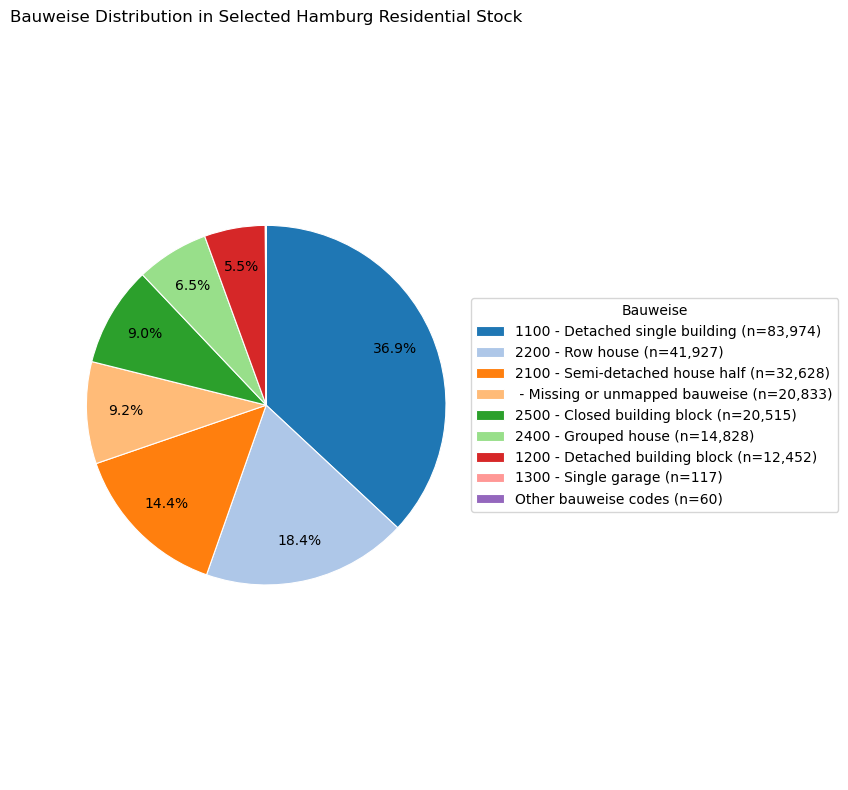

Residential buildings in chart: 227334
Output: ../results/maps/hamburg_residential_bauweise_pie_chart.png


,bauweise,building_count,share_pct
0,1100 - Detached single building,83974,36.94
1,2200 - Row house,41927,18.44
2,2100 - Semi-detached house half,32628,14.35
3,- Missing or unmapped bauweise,20833,9.16
4,2500 - Closed building block,20515,9.02
5,2400 - Grouped house,14828,6.52
6,1200 - Detached building block,12452,5.48
7,1300 - Single garage,117,0.05
8,1400 - Double garage,42,0.02
9,1500 - Collective garage,18,0.01


In [9]:
BAUWEISE_CODE_LABELS_EN = {
    "1100": "Detached single building",
    "1200": "Detached building block",
    "1300": "Single garage",
    "1400": "Double garage",
    "1500": "Collective garage",
    "2100": "Semi-detached house half",
    "2200": "Row house",
    "2300": "House in a row",
    "2400": "Grouped house",
    "2500": "Closed building block",
    "4000": "Open hall",
    "9999": "Unknown bauweise",
}

bauweise_pie_gdf = gdf_stock.copy()
bauweise_pie_gdf["bauweise_code_for_chart"] = bauweise_pie_gdf["bauweise_code"].fillna("missing")
bauweise_pie_gdf["bauweise_label_en"] = bauweise_pie_gdf["bauweise_code_for_chart"].map(
    BAUWEISE_CODE_LABELS_EN
).fillna("Missing or unmapped bauweise")
bauweise_pie_gdf.loc[bauweise_pie_gdf["bauweise_code_for_chart"].eq("missing"), "bauweise_label_en"] = "Missing bauweise"
bauweise_pie_gdf["bauweise_chart_label"] = (
    bauweise_pie_gdf["bauweise_code_for_chart"].astype("string")
    + " - "
    + bauweise_pie_gdf["bauweise_label_en"].astype("string")
)
bauweise_pie_gdf.loc[
    bauweise_pie_gdf["bauweise_code_for_chart"].eq("missing"),
    "bauweise_chart_label",
] = "Missing bauweise"

bauweise_pie_counts = (
    bauweise_pie_gdf["bauweise_chart_label"]
    .value_counts(dropna=False)
    .rename_axis("bauweise")
    .reset_index(name="building_count")
)
bauweise_pie_counts["share_pct"] = (
    bauweise_pie_counts["building_count"] / len(bauweise_pie_gdf) * 100
).round(2)

TOP_N_BAUWEISE_SLICES = 8
top_bauweise = bauweise_pie_counts.head(TOP_N_BAUWEISE_SLICES).copy()
other_count = bauweise_pie_counts.iloc[TOP_N_BAUWEISE_SLICES:]["building_count"].sum()
if other_count > 0:
    top_bauweise = pd.concat(
        [
            top_bauweise,
            pd.DataFrame({"bauweise": ["Other bauweise codes"], "building_count": [other_count]}),
        ],
        ignore_index=True,
    )
top_bauweise["share_pct"] = (top_bauweise["building_count"] / len(bauweise_pie_gdf) * 100).round(2)

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.get_cmap("tab20").colors[: len(top_bauweise)]
wedges, _, autotexts = ax.pie(
    top_bauweise["building_count"],
    startangle=90,
    counterclock=False,
    colors=colors,
    autopct=lambda pct: f"{pct:.1f}%" if pct >= 2 else "",
    pctdistance=0.78,
    wedgeprops={"linewidth": 0.8, "edgecolor": "white"},
)
ax.set_title("Bauweise Distribution in Selected Hamburg Residential Stock")
ax.axis("equal")
legend_labels = [
    f"{row.bauweise} (n={row.building_count:,})"
    for row in top_bauweise.itertuples(index=False)
]
ax.legend(
    wedges,
    legend_labels,
    title="Bauweise",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    frameon=True,
)
plt.tight_layout()

bauweise_pie_output_path = MAP_DIR / "hamburg_residential_bauweise_pie_chart.png"
plt.savefig(bauweise_pie_output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Residential buildings in chart:", len(bauweise_pie_gdf))
print("Output:", bauweise_pie_output_path)
display(bauweise_pie_counts)


## Bauweise Validation Flags

`bauweise` is treated as the direct classification source. Storeys and footprint are used only as validation flags and do not override direct `bauweise` classes.

In [10]:
bauweise_validation_summary = (
    gdf_residential_stock
    .groupby([
        "bauweise_direct_form",
        "bauweise_storey_validation",
        "bauweise_footprint_validation",
        "bauweise_quality_flags",
    ], dropna=False)
    .size()
    .reset_index(name="building_count")
    .sort_values("building_count", ascending=False)
)
bauweise_validation_summary["share_pct"] = (
    bauweise_validation_summary["building_count"] / len(gdf_residential_stock) * 100
).round(2)
bauweise_validation_summary


,bauweise_direct_form,bauweise_storey_validation,bauweise_footprint_validation,bauweise_quality_flags,building_count,share_pct
6,SFH,ok,ok,ok,162830,71.63
0,MFH,ok,ok,ok,22982,10.11
12,unresolved,not_applicable,not_applicable,not_applicable,20833,9.16
8,SFH,outside_expected_range,ok,storeys:outside_expected_range,9418,4.14
2,MFH,outside_expected_range,ok,storeys:outside_expected_range,9410,4.14
9,SFH,outside_expected_range,outside_expected_range,storeys:outside_expected_range;footprint:outsi...,493,0.22
7,SFH,ok,outside_expected_range,footprint:outside_expected_range,490,0.22
3,MFH,outside_expected_range,outside_expected_range,storeys:outside_expected_range;footprint:outsi...,311,0.14
1,MFH,ok,outside_expected_range,footprint:outside_expected_range,233,0.10
11,auxiliary_non_residential,not_applicable,not_applicable,not_applicable,177,0.08


## Export Residential Analysis Dataset

In [11]:
gdf_residential_stock.to_file(RESIDENTIAL_ANALYSIS_PATH, driver="GPKG")
print("Residential stock-analysis buildings:", len(gdf_residential_stock))
print("Output:", RESIDENTIAL_ANALYSIS_PATH)

gdf_residential_stock[[
    "gebaeudefunktion",
    "building_function",
    "bauweise",
    "bauweise_code",
    "bauweise_label",
    "bauweise_direct_form",
    "bauweise_quality_flags",
    "baujahr",
    "construction_year",
    "construction_year_status",
    "anzahlDerOberirdischenGeschosse",
    "storeys",
    "footprint_area",
]].head()


Residential stock-analysis buildings: 227334
Output: ../data/processed/residential_buildings_for_analysis.gpkg


,gebaeudefunktion,building_function,bauweise,bauweise_code,bauweise_label,bauweise_direct_form,bauweise_quality_flags,baujahr,construction_year,construction_year_status,anzahlDerOberirdischenGeschosse,storeys,footprint_area
0,1010,1010,1100,1100,Freistehendes Einzelgebaeude,SFH,ok,NULL,<NA>,missing,1,1.0,60.119327
1,1010,1010,1100,1100,Freistehendes Einzelgebaeude,SFH,ok,NULL,<NA>,missing,1,1.0,145.589780
2,1010,1010,1100,1100,Freistehendes Einzelgebaeude,SFH,ok,NULL,<NA>,missing,1,1.0,123.686803
3,1010,1010,1100,1100,Freistehendes Einzelgebaeude,SFH,ok,1997,1997,single_year,2,2.0,113.674547
4,1010,1010,2200,2200,Reihenhaus,SFH,ok,1978,1978,single_year,2,2.0,67.539725


## Map: Residential Analysis Scope


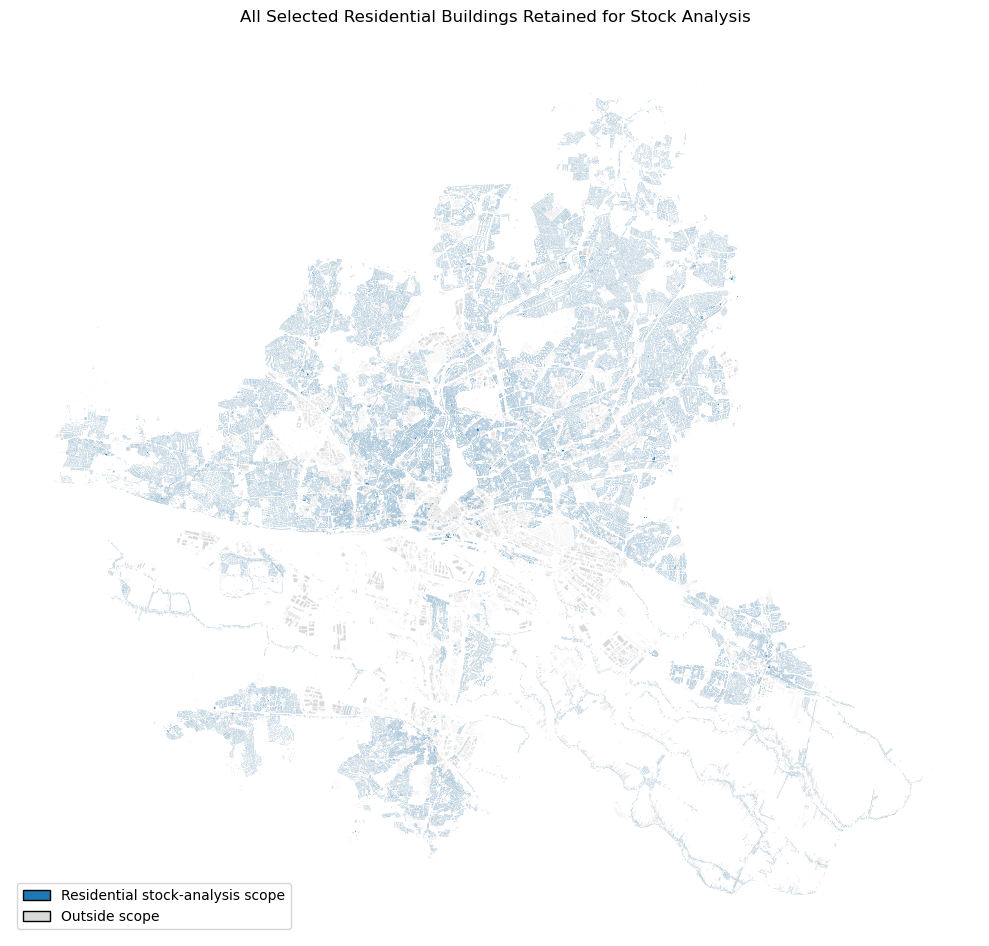

Buildings mapped: 227334
Output: ../results/maps/residential_analysis_scope_map.png


In [12]:
if gdf_residential_stock.empty:
    raise ValueError("No residential buildings retained for analysis. Check filter conditions.")

fig, ax = plt.subplots(figsize=(10, 10))
gdf_all.plot(ax=ax, color="#d9d9d9", linewidth=0.05, edgecolor="white")
gdf_residential_stock.plot(ax=ax, color="#1f78b4", linewidth=0.05, edgecolor="white")

handles = [
    Patch(facecolor="#1f78b4", edgecolor="black", label="Residential stock-analysis scope"),
    Patch(facecolor="#d9d9d9", edgecolor="black", label="Outside scope"),
]
ax.legend(handles=handles, loc="lower left", frameon=True)
ax.set_title("All Selected Residential Buildings Retained for Stock Analysis")
ax.set_axis_off()
plt.tight_layout()

map_output_path = MAP_DIR / "residential_analysis_scope_map.png"
plt.savefig(map_output_path, dpi=600, bbox_inches="tight")
plt.show()

print("Buildings mapped:", len(gdf_residential_stock))
print("Output:", map_output_path)


## Map: Bauweise-Based Building Form

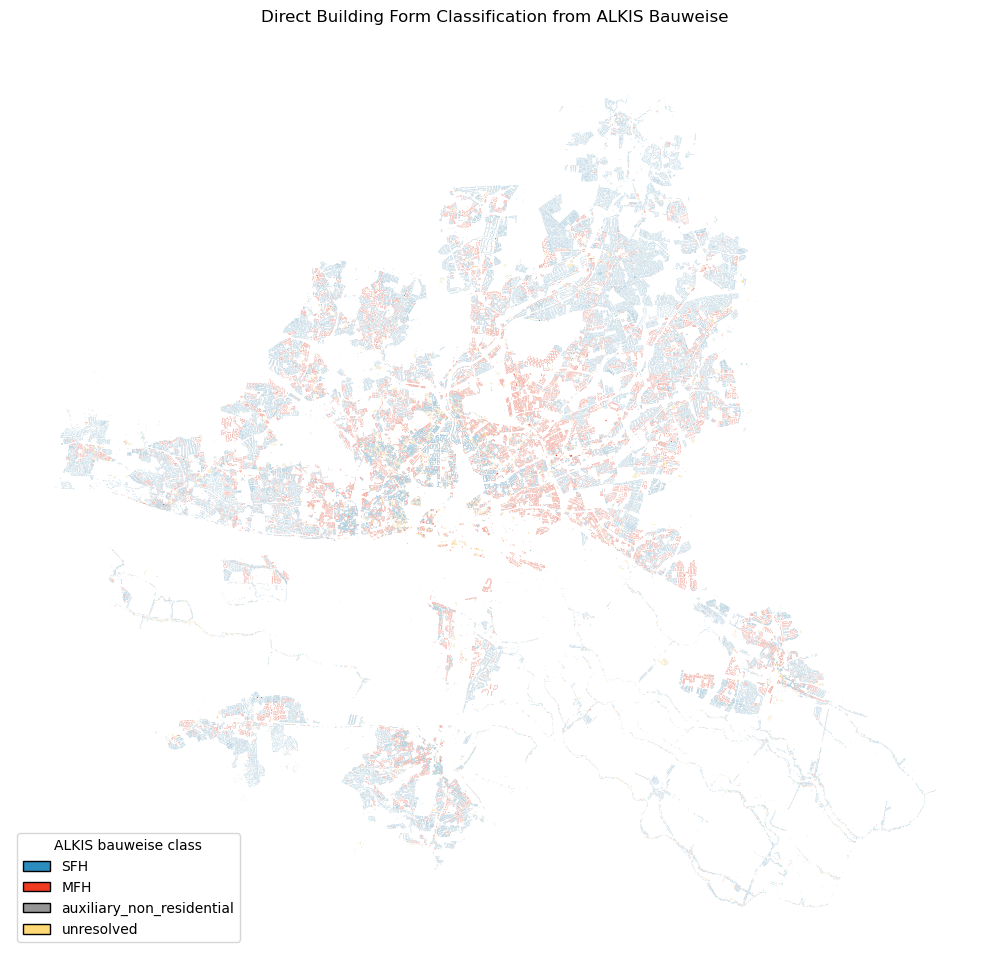

Buildings mapped: 227334
Output: ../results/maps/hamburg_bauweise_direct_building_form_map.png


In [13]:
plot_gdf = gdf_residential_stock.copy()
map_colors = {
    "SFH": "#2b8cbe",
    "MFH": "#f03b20",
    "auxiliary_non_residential": "#969696",
    "non_residential": "#525252",
    "unresolved": "#fed976",
}
plot_gdf["map_color"] = plot_gdf["bauweise_direct_form"].map(map_colors).fillna("#fed976")

fig, ax = plt.subplots(figsize=(10, 10))
gdf_stock.plot(ax=ax, color="#eeeeee", linewidth=0.03, edgecolor="white")
plot_gdf.plot(ax=ax, color=plot_gdf["map_color"], linewidth=0.05, edgecolor="white")

handles = [
    Patch(facecolor=map_colors[k], edgecolor="black", label=k)
    for k in map_colors
    if k in set(plot_gdf["bauweise_direct_form"])
]
ax.legend(handles=handles, title="ALKIS bauweise class", loc="lower left", frameon=True)
ax.set_title("Direct Building Form Classification from ALKIS Bauweise")
ax.set_axis_off()
plt.tight_layout()

map_output_path = MAP_DIR / "hamburg_bauweise_direct_building_form_map.png"
plt.savefig(map_output_path, dpi=600, bbox_inches="tight")
plt.show()

print("Buildings mapped:", len(plot_gdf))
print("Output:", map_output_path)
